# 仮想水輸出が多い20傑

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

# ===== 設定 =====
VWT_DIR = Path(r"C:\修論研究\VWT_historical_data\VWT_npy")
ITEM_LIST_XLSX = r"C:\修論研究\VWT_historical_data\item_list.xlsx"
YEAR = 2016
TOP_N = 20

# ===== 2016年の作物別・世界総仮想水輸出量を集計 =====
pat = re.compile(rf"^VWT_(\d+)_{YEAR}\.npy$")
rows = []

for p in VWT_DIR.glob(f"VWT_*_{YEAR}.npy"):
    m = pat.match(p.name)
    if not m:
        continue
    crop_id = int(m.group(1))
    vwt_mat = np.load(p).astype(float)
    if vwt_mat.ndim != 2:
        continue

    # 世界総輸出量（行列全要素の合計）
    world_export_total = float(np.nansum(vwt_mat))
    rows.append(
        {
            "crop_id": crop_id,
            "world_export_total_m3_per_year": world_export_total,
        }
    )

top20 = (
    pd.DataFrame(rows)
    .sort_values("world_export_total_m3_per_year", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

# ===== item_list.xlsx から Commodity name を付与 =====
item_df = pd.read_excel(ITEM_LIST_XLSX)

def find_col(cols, exact=None, contains=None):
    exact = exact or []
    contains = contains or []
    lowered = {str(c).strip().lower(): c for c in cols}
    for k in exact:
        if k.lower() in lowered:
            return lowered[k.lower()]
    for c in cols:
        low = str(c).strip().lower()
        if all(token in low for token in contains):
            return c
    return None

fao_col = find_col(
    item_df.columns,
    exact=["FAO code", "fao code", "FAO_code", "fao_code"],
    contains=["fao", "code"],
)
name_col = find_col(
    item_df.columns,
    exact=["Commodity name", "commodity name", "Item name", "item name"],
    contains=["commodity", "name"],
)

if fao_col is None or name_col is None:
    raise ValueError(f"item_list.xlsx の列を特定できません。columns={list(item_df.columns)}")

item_map = item_df[[fao_col, name_col]].copy()
item_map = item_map.rename(columns={fao_col: "crop_id", name_col: "commodity_name"})
item_map["crop_id"] = pd.to_numeric(item_map["crop_id"], errors="coerce").astype("Int64")
item_map = item_map.dropna(subset=["crop_id"]).copy()
item_map["crop_id"] = item_map["crop_id"].astype(int)
item_map = item_map.drop_duplicates(subset=["crop_id"], keep="first")

# ===== 結合して表示 =====
top20_named = top20.merge(item_map, on="crop_id", how="left")
top20_named = top20_named[["crop_id", "commodity_name", "world_export_total_m3_per_year"]]
top20_named.index = top20_named.index + 1
top20_named.index.name = "rank"

display(top20_named)
print("top20 crop_id:", top20_named["crop_id"].tolist())


,crop_id,commodity_name,world_export_total_m3_per_year
rank,,,
1,15,Wheat,2.213492e+11
2,236,Soybeans,2.195880e+11
3,257,Palm oil,1.672256e+11
4,56,Maize,1.070263e+11
5,238,Cake of Soybeans,9.880626e+10
6,666,Chocolate Prsnes,9.501316e+10
7,30,Rice - total (Rice milled equivalent),9.176010e+10
8,656,"Coffee, green",8.466443e+10
9,661,Cocoa beans,7.100909e+10


top20 crop_id: [15, 236, 257, 56, 238, 666, 30, 656, 661, 767, 162, 237, 270, 268, 164, 664, 44, 167, 261, 271]


# 各国の20傑作物の輸出入動向を調べ、グループ化（主成分分析）一人当たりの方がいいかな

In [5]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

# ===== 設定 =====
VWT_DIR = Path(r"C:\修論研究\VWT_historical_data\VWT_npy")
ITEM_LIST_XLSX = r"C:\修論研究\VWT_historical_data\item_list.xlsx"
YEAR = 2016
TOP_N = 20

# ===== 2016年の作物別・世界総仮想水輸出量を集計 =====
pat = re.compile(rf"^VWT_(\d+)_{YEAR}\.npy$")
rows = []

for p in VWT_DIR.glob(f"VWT_*_{YEAR}.npy"):
    m = pat.match(p.name)
    if not m:
        continue
    crop_id = int(m.group(1))
    vwt_mat = np.load(p).astype(float)
    if vwt_mat.ndim != 2:
        continue

    # 世界総輸出量（行列全要素の合計）
    world_export_total = float(np.nansum(vwt_mat))
    rows.append(
        {
            "crop_id": crop_id,
            "world_export_total_m3_per_year": world_export_total,
        }
    )

top20 = (
    pd.DataFrame(rows)
    .sort_values("world_export_total_m3_per_year", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

# ===== item_list.xlsx から Commodity name を付与 =====
item_df = pd.read_excel(ITEM_LIST_XLSX)

def find_col(cols, exact=None, contains=None):
    exact = exact or []
    contains = contains or []
    lowered = {str(c).strip().lower(): c for c in cols}
    for k in exact:
        if k.lower() in lowered:
            return lowered[k.lower()]
    for c in cols:
        low = str(c).strip().lower()
        if all(token in low for token in contains):
            return c
    return None

fao_col = find_col(
    item_df.columns,
    exact=["FAO code", "fao code", "FAO_code", "fao_code"],
    contains=["fao", "code"],
)
name_col = find_col(
    item_df.columns,
    exact=["Commodity name", "commodity name", "Item name", "item name"],
    contains=["commodity", "name"],
)

if fao_col is None or name_col is None:
    raise ValueError(f"item_list.xlsx の列を特定できません。columns={list(item_df.columns)}")

item_map = item_df[[fao_col, name_col]].copy()
item_map = item_map.rename(columns={fao_col: "crop_id", name_col: "commodity_name"})
item_map["crop_id"] = pd.to_numeric(item_map["crop_id"], errors="coerce").astype("Int64")
item_map = item_map.dropna(subset=["crop_id"]).copy()
item_map["crop_id"] = item_map["crop_id"].astype(int)
item_map = item_map.drop_duplicates(subset=["crop_id"], keep="first")

# ===== 結合して表示 =====
top20_named = top20.merge(item_map, on="crop_id", how="left")
top20_named = top20_named[["crop_id", "commodity_name", "world_export_total_m3_per_year"]]
top20_named.index = top20_named.index + 1
top20_named.index.name = "rank"

display(top20_named)
print("top20 crop_id:", top20_named["crop_id"].tolist())


,crop_id,commodity_name,world_export_total_m3_per_year
rank,,,
1,15,Wheat,2.213492e+11
2,236,Soybeans,2.195880e+11
3,257,Palm oil,1.672256e+11
4,56,Maize,1.070263e+11
5,238,Cake of Soybeans,9.880626e+10
6,666,Chocolate Prsnes,9.501316e+10
7,30,Rice - total (Rice milled equivalent),9.176010e+10
8,656,"Coffee, green",8.466443e+10
9,661,Cocoa beans,7.100909e+10


top20 crop_id: [15, 236, 257, 56, 238, 666, 30, 656, 661, 767, 162, 237, 270, 268, 164, 664, 44, 167, 261, 271]


In [6]:
store = load_vwt_trade_npy_store(str(STORE_DIR))

crop_ids = store["crop_ids"].astype(int)
years = store["years"].astype(int)
iso3_order = store["iso3_order"].astype(str)

rows = []
for ci, crop in enumerate(crop_ids):
    for yi, y in enumerate(years):
        rows.append(
            pd.DataFrame(
                {
                    "year": int(y),
                    "iso3": iso3_order,
                    "crop_id": int(crop),
                    "import_pc_m3_per_person_per_year": store["import_pc"][ci, yi, :],
                    "export_pc_m3_per_person_per_year": store["export_pc"][ci, yi, :],
                    "net_pc_m3_per_person_per_year": store["net_pc"][ci, yi, :],
                    "population_used": store["population_used"][ci, yi, :],
                }
            )
        )

top20_net_pc_2016 = pd.concat(rows, ignore_index=True)
top20_net_pc_2016 = top20_net_pc_2016.merge(
    top20_named[["crop_id", "commodity_name"]],
    on="crop_id",
    how="left",
)
top20_net_pc_2016 = top20_net_pc_2016[
    [
        "year",
        "iso3",
        "crop_id",
        "commodity_name",
        "import_pc_m3_per_person_per_year",
        "export_pc_m3_per_person_per_year",
        "net_pc_m3_per_person_per_year",
        "population_used",
    ]
]

top20_net_pc_2016.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

MATRIX_CSV = STORE_DIR / "top20_net_pc_2016_matrix_iso3_x_crop.csv"
MATRIX_NPY = STORE_DIR / "top20_net_pc_2016_matrix.npy"
MATRIX_ISO3_NPY = STORE_DIR / "top20_net_pc_2016_matrix_iso3.npy"
MATRIX_CROP_NPY = STORE_DIR / "top20_net_pc_2016_matrix_crop_ids.npy"

top20_net_pc_2016_matrix = (
    top20_net_pc_2016.pivot_table(
        index="iso3",
        columns="crop_id",
        values="net_pc_m3_per_person_per_year",
        aggfunc="first",
    )
    .sort_index()
    .reindex(columns=top20_crop_ids)
)

top20_net_pc_2016_matrix.to_csv(MATRIX_CSV, encoding="utf-8-sig")
np.save(MATRIX_NPY, top20_net_pc_2016_matrix.to_numpy(dtype=float))
np.save(MATRIX_ISO3_NPY, top20_net_pc_2016_matrix.index.to_numpy(dtype=str))
np.save(MATRIX_CROP_NPY, np.array(top20_net_pc_2016_matrix.columns, dtype=int))

display(top20_net_pc_2016.head())
display(top20_net_pc_2016_matrix.head())
print(f"saved long table: {OUT_CSV}")
print(f"saved matrix csv: {MATRIX_CSV}")
print(f"saved matrix npy: {MATRIX_NPY}")
print(f"rows={len(top20_net_pc_2016):,}, valid net_pc={top20_net_pc_2016['net_pc_m3_per_person_per_year'].notna().sum():,}")


,year,iso3,crop_id,commodity_name,import_pc_m3_per_person_per_year,export_pc_m3_per_person_per_year,net_pc_m3_per_person_per_year,population_used
0,2016,ABW,15,Wheat,3.892397,0.000000,3.892397,108727.0
1,2016,AFG,15,Wheat,19.369136,0.000000,19.369136,34700612.0
2,2016,AGO,15,Wheat,0.005489,0.000000,0.005489,29183070.0
3,2016,AIA,15,Wheat,NaN,NaN,NaN,NaN
4,2016,ALB,15,Wheat,108.613344,0.290665,108.322678,2689469.0


crop_id,15,236,257,56,238,666,30,656,661,767,162,237,270,268,164,664,44,167,261,271
iso3,,,,,,,,,,,,,,,,,,,,
ABW,3.892397,0.068022,0.346249,4.100628,-2.699861,90.974059,103.606109,0.725481,-3.761322,1.442200,4.182544,14.761979,0.0,5.280745,36.181594,0.000000,0.000000,84.138149,19.767708,9.207839
AFG,19.369136,0.000000,11.717821,0.209644,0.055457,0.899920,31.650898,0.000000,0.000000,-15.877731,1.261230,0.000665,0.0,5.772433,16.236739,0.000000,0.839171,0.023907,0.025998,0.001867
AGO,0.005489,0.028841,17.408525,0.975031,0.427059,1.604753,44.070041,-1.294885,0.000000,0.000747,0.141859,7.306871,0.0,1.839359,10.411894,0.002597,0.001720,0.166808,1.904138,0.004453
ALB,108.322678,0.014333,3.157927,11.721007,12.641954,27.536992,19.404516,17.305657,0.000000,0.008961,0.036723,0.666772,0.0,32.083439,25.079561,0.000000,1.126308,0.397732,6.474324,0.013208
AND,0.000000,0.000000,0.000000,0.000000,0.000000,32.405899,0.000000,0.000000,0.592892,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


saved long table: C:\修論研究\codes\vwt_trade_store_top20_2016\top20_net_pc_2016_long.csv
saved matrix csv: C:\修論研究\codes\vwt_trade_store_top20_2016\top20_net_pc_2016_matrix_iso3_x_crop.csv
saved matrix npy: C:\修論研究\codes\vwt_trade_store_top20_2016\top20_net_pc_2016_matrix.npy
rows=4,600, valid net_pc=4,200


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
from percapita_utils import build_vwt_trade_npy_store_all_crops, load_vwt_trade_npy_store

# 依存セルを実行していなくても動くように既定値を設定
if "YEAR" not in globals():
    YEAR = 2016
if "COUNTRY_POP_CSV" not in globals():
    COUNTRY_POP_CSV = r"C:\修論研究\VWT_historical_data\country_population.csv"
if "COUNTRY_LIST_XLSX" not in globals():
    COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
if "VWT_NPY_TEMPLATE" not in globals():
    VWT_NPY_TEMPLATE = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
if "STORE_DIR" not in globals():
    STORE_DIR = Path(r"C:\修論研究\codes\vwt_trade_store_top20_2016")
if "OUT_CSV" not in globals():
    OUT_CSV = STORE_DIR / "top20_net_pc_2016_long.csv"
if "ITEM_LIST_XLSX" not in globals():
    ITEM_LIST_XLSX = r"C:\修論研究\VWT_historical_data\item_list.xlsx"
if "top20_crop_ids" not in globals():
    top20_crop_ids = [15, 236, 257, 56, 238, 666, 30, 656, 661, 767, 162, 237, 270, 268, 164, 664, 44, 167, 261, 271]


def _find_col(cols, exact=None, contains=None):
    exact = exact or []
    contains = contains or []
    lowered = {str(c).strip().lower(): c for c in cols}
    for k in exact:
        if k.lower() in lowered:
            return lowered[k.lower()]
    for c in cols:
        low = str(c).strip().lower()
        if all(token in low for token in contains):
            return c
    return None


def _build_commodity_map() -> pd.DataFrame:
    item_df = pd.read_excel(ITEM_LIST_XLSX)
    fao_col = _find_col(
        item_df.columns,
        exact=["FAO code", "fao code", "FAO_code", "fao_code"],
        contains=["fao", "code"],
    )
    name_col = _find_col(
        item_df.columns,
        exact=["Commodity name", "commodity name", "Item name", "item name"],
        contains=["commodity", "name"],
    )
    if fao_col is None or name_col is None:
        return pd.DataFrame({"crop_id": top20_crop_ids, "commodity_name": [np.nan] * len(top20_crop_ids)})

    item_map = item_df[[fao_col, name_col]].copy()
    item_map = item_map.rename(columns={fao_col: "crop_id", name_col: "commodity_name"})
    item_map["crop_id"] = pd.to_numeric(item_map["crop_id"], errors="coerce")
    item_map = item_map.dropna(subset=["crop_id"]).copy()
    item_map["crop_id"] = item_map["crop_id"].astype(int)
    item_map = item_map.drop_duplicates(subset=["crop_id"], keep="first")
    return item_map


def _build_top20_long_from_store(store: dict) -> pd.DataFrame:
    crop_ids = store["crop_ids"].astype(int)
    years = store["years"].astype(int)
    iso3_order = store["iso3_order"].astype(str)

    rows = []
    for ci, crop in enumerate(crop_ids):
        for yi, y in enumerate(years):
            rows.append(
                pd.DataFrame(
                    {
                        "year": int(y),
                        "iso3": iso3_order,
                        "crop_id": int(crop),
                        "import_pc_m3_per_person_per_year": store["import_pc"][ci, yi, :],
                        "export_pc_m3_per_person_per_year": store["export_pc"][ci, yi, :],
                        "net_pc_m3_per_person_per_year": store["net_pc"][ci, yi, :],
                        "population_used": store["population_used"][ci, yi, :],
                    }
                )
            )

    df = pd.concat(rows, ignore_index=True)
    item_map = _build_commodity_map()
    df = df.merge(item_map[["crop_id", "commodity_name"]], on="crop_id", how="left")

    df = df[
        [
            "year",
            "iso3",
            "crop_id",
            "commodity_name",
            "import_pc_m3_per_person_per_year",
            "export_pc_m3_per_person_per_year",
            "net_pc_m3_per_person_per_year",
            "population_used",
        ]
    ]

    matrix = (
        df.pivot_table(
            index="iso3",
            columns="crop_id",
            values="net_pc_m3_per_person_per_year",
            aggfunc="first",
        )
        .sort_index()
        .reindex(columns=top20_crop_ids)
    )

    STORE_DIR.mkdir(parents=True, exist_ok=True)
    df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
    matrix.to_csv(STORE_DIR / "top20_net_pc_2016_matrix_iso3_x_crop.csv", encoding="utf-8-sig")
    np.save(STORE_DIR / "top20_net_pc_2016_matrix.npy", matrix.to_numpy(dtype=float))
    np.save(STORE_DIR / "top20_net_pc_2016_matrix_iso3.npy", matrix.index.to_numpy(dtype=str))
    np.save(STORE_DIR / "top20_net_pc_2016_matrix_crop_ids.npy", np.array(matrix.columns, dtype=int))

    return df


def ensure_top20_net_pc_2016_ready() -> pd.DataFrame:
    if "top20_net_pc_2016" in globals() and isinstance(top20_net_pc_2016, pd.DataFrame) and len(top20_net_pc_2016) > 0:
        return top20_net_pc_2016.copy()

    if OUT_CSV.exists():
        return pd.read_csv(OUT_CSV)

    crop_ids_npy = STORE_DIR / "crop_ids.npy"
    years_npy = STORE_DIR / "years.npy"
    if crop_ids_npy.exists() and years_npy.exists():
        store = load_vwt_trade_npy_store(str(STORE_DIR))
        return _build_top20_long_from_store(store)

    country_population = pd.read_csv(COUNTRY_POP_CSV)
    summary = build_vwt_trade_npy_store_all_crops(
        crops=top20_crop_ids,
        year_start=YEAR,
        year_end=YEAR,
        country_list_xlsx=COUNTRY_LIST_XLSX,
        vwt_npy_template=VWT_NPY_TEMPLATE,
        population_df=country_population,
        out_dir=str(STORE_DIR),
        pop_iso3_col="Country Code",
        pop_year_col="Year",
        pop_value_col="Value",
    )
    display(summary)

    store = load_vwt_trade_npy_store(str(STORE_DIR))
    return _build_top20_long_from_store(store)


def load_top20_net_pc_2016(path: str | Path = OUT_CSV) -> pd.DataFrame:
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    return ensure_top20_net_pc_2016_ready()


def load_top20_net_pc_2016_matrix(
    path: str | Path = STORE_DIR / "top20_net_pc_2016_matrix_iso3_x_crop.csv",
) -> pd.DataFrame:
    p = Path(path)
    if p.exists():
        return pd.read_csv(p, index_col=0)
    _ = ensure_top20_net_pc_2016_ready()
    return pd.read_csv(p, index_col=0)


def get_top20_net_pc_2016(
    iso3: str | None = None,
    crop_id: int | None = None,
    *,
    sort_by_abs_net: bool = True,
    ascending: bool = False,
) -> pd.DataFrame:
    df = load_top20_net_pc_2016()
    if iso3 is not None:
        df = df[df["iso3"].str.upper() == str(iso3).upper()]
    if crop_id is not None:
        df = df[df["crop_id"] == int(crop_id)]

    if sort_by_abs_net:
        df = (
            df.assign(abs_net_pc=df["net_pc_m3_per_person_per_year"].abs())
            .sort_values("abs_net_pc", ascending=ascending)
            .drop(columns=["abs_net_pc"])
        )
    return df.reset_index(drop=True)


# このセルだけで利用可能（未保存でも自動生成してから表示）
display(get_top20_net_pc_2016(iso3="JPN").head(10))
display(get_top20_net_pc_2016(crop_id=30).head(10))
display(load_top20_net_pc_2016_matrix().head())


,year,iso3,crop_id,commodity_name,import_pc_m3_per_person_per_year,export_pc_m3_per_person_per_year,net_pc_m3_per_person_per_year,population_used
0,2016,JPN,56,Maize,77.539794,0.000206,77.539588,127076000.0
1,2016,JPN,15,Wheat,61.027573,0.007364,61.020210,127076000.0
2,2016,JPN,656,"Coffee, green",36.989941,0.074232,36.915710,127076000.0
3,2016,JPN,236,Soybeans,34.531614,0.003264,34.528350,127076000.0
4,2016,JPN,270,Rapeseed,33.196782,0.019365,33.177417,127076000.0
5,2016,JPN,666,Chocolate Prsnes,24.923240,0.937780,23.985461,127076000.0
6,2016,JPN,238,Cake of Soybeans,20.265647,0.006820,20.258827,127076000.0
7,2016,JPN,257,Palm oil,16.889840,0.003130,16.886710,127076000.0
8,2016,JPN,162,Sugar Raw Centrifugal,13.646857,0.008185,13.638672,127076000.0
9,2016,JPN,30,Rice - total (Rice milled equivalent),12.949436,0.328491,12.620945,127076000.0


,year,iso3,crop_id,commodity_name,import_pc_m3_per_person_per_year,export_pc_m3_per_person_per_year,net_pc_m3_per_person_per_year,population_used
0,2016,GUY,30,Rice - total (Rice milled equivalent),0.448661,1253.581529,-1253.132868,763548.0
1,2016,TCA,30,Rice - total (Rice milled equivalent),59.932542,740.426439,-680.493897,38315.0
2,2016,ATG,30,Rice - total (Rice milled equivalent),41.012417,642.698763,-601.686346,89969.0
3,2016,BEN,30,Rice - total (Rice milled equivalent),524.593447,0.140624,524.452823,11697842.0
4,2016,DJI,30,Rice - total (Rice milled equivalent),414.751732,0.000000,414.751732,1037653.0
5,2016,THA,30,Rice - total (Rice milled equivalent),7.841681,419.046029,-411.204348,70859841.0
6,2016,URY,30,Rice - total (Rice milled equivalent),0.835249,399.568489,-398.733240,3379283.0
7,2016,KIR,30,Rice - total (Rice milled equivalent),252.354717,0.000000,252.354717,118478.0
8,2016,BRN,30,Rice - total (Rice milled equivalent),200.320713,0.000000,200.320713,427564.0
9,2016,ARE,30,Rice - total (Rice milled equivalent),318.908909,129.050763,189.858146,8935095.0


,15,236,257,56,238,666,30,656,661,767,162,237,270,268,164,664,44,167,261,271
iso3,,,,,,,,,,,,,,,,,,,,
ABW,3.892397,0.068022,0.346249,4.100628,-2.699861,90.974059,103.606109,0.725481,-3.761322,1.442200,4.182544,14.761979,0.0,5.280745,36.181594,0.000000,0.000000,84.138149,19.767708,9.207839
AFG,19.369136,0.000000,11.717821,0.209644,0.055457,0.899920,31.650898,0.000000,0.000000,-15.877731,1.261230,0.000665,0.0,5.772433,16.236739,0.000000,0.839171,0.023907,0.025998,0.001867
AGO,0.005489,0.028841,17.408525,0.975031,0.427059,1.604753,44.070041,-1.294885,0.000000,0.000747,0.141859,7.306871,0.0,1.839359,10.411894,0.002597,0.001720,0.166808,1.904138,0.004453
ALB,108.322678,0.014333,3.157927,11.721007,12.641954,27.536992,19.404516,17.305657,0.000000,0.008961,0.036723,0.666772,0.0,32.083439,25.079561,0.000000,1.126308,0.397732,6.474324,0.013208
AND,0.000000,0.000000,0.000000,0.000000,0.000000,32.405899,0.000000,0.000000,0.592892,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# 各国について、2016年度の例の20作物の一人当たりnetの主成分分析

countries used: 210 / 230
n_components: 5
saved: C:\修論研究\codes\vwt_trade_store_top20_2016\pca_2016_top20_net_pc
marker size range: 10.0 - 2500.0


C:\Users\tsuda\AppData\Local\Temp\ipykernel_26204\986546617.py:104: RuntimeWarning: All-NaN slice encountered
  pop_by_iso3 = pd.Series(np.nanmedian(POP, axis=1), index=iso3, name="population")


,PC,explained_variance_ratio,cumulative_ratio
0,PC1,0.154609,0.154609
1,PC2,0.100860,0.255468
2,PC3,0.081725,0.337193
3,PC4,0.073892,0.411085
4,PC5,0.060601,0.471686


,iso3,population,marker_size,PC1,PC2,PC3,PC4,PC5
0,ABW,108727.0,10.175471,0.147400,-0.723519,1.249526,1.888584,1.236914
1,AFG,34700612.0,72.241397,-0.021118,0.166920,0.097684,-0.080156,-0.156055
2,AGO,29183070.0,62.341637,0.012275,0.071816,0.047456,-0.099754,-0.083173
3,ALB,2689469.0,14.805925,0.404042,0.255277,0.150086,0.056256,0.171457
4,AND,72181.0,10.109899,-0.162225,-0.013516,-0.228351,0.140738,0.054462


,PC1,PC2,PC3,PC4,PC5
15_Wheat,0.362332,0.393494,-0.026117,0.122680,-0.014934
236_Soybeans,0.279268,-0.149928,0.002514,-0.015659,-0.181475
257_Palm oil,0.051432,0.139367,0.512252,-0.164545,-0.300470
56_Maize,0.471381,-0.155527,-0.099986,-0.002990,-0.008278
238_Cake of Soybeans,0.419793,-0.372744,-0.064436,-0.070904,-0.016501
666_Chocolate Prsnes,-0.059772,-0.193592,0.047164,0.538375,0.129480
30_Rice - total (Rice milled equivalent),0.137749,0.016934,0.391615,0.112643,0.040734
"656_Coffee, green",0.042921,0.035914,0.070478,-0.460324,0.327861
661_Cocoa beans,0.008351,0.033408,-0.032427,-0.199654,0.087151
767_Cotton lint,0.068228,0.079111,-0.130275,-0.057372,0.296465


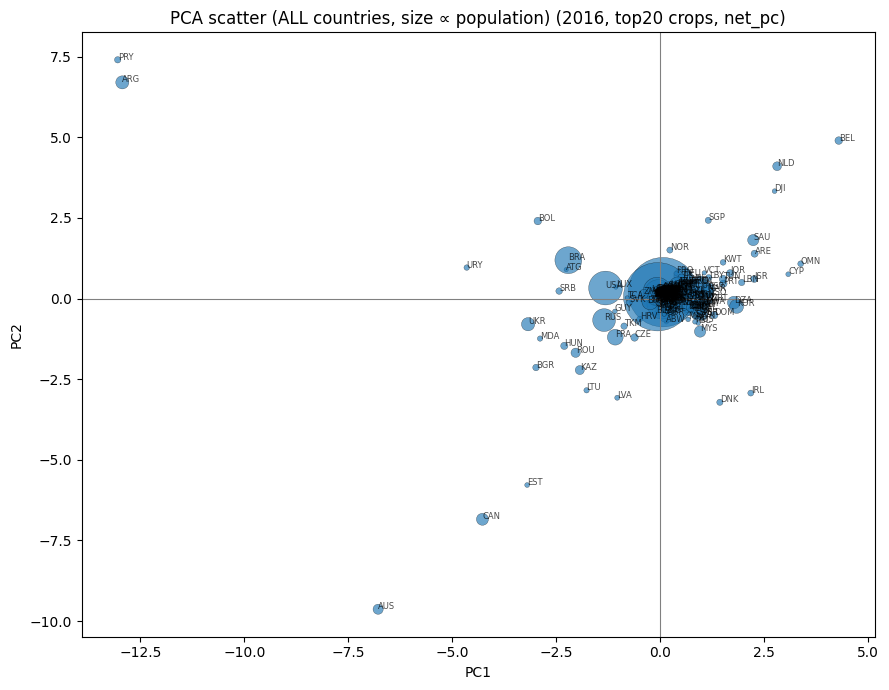

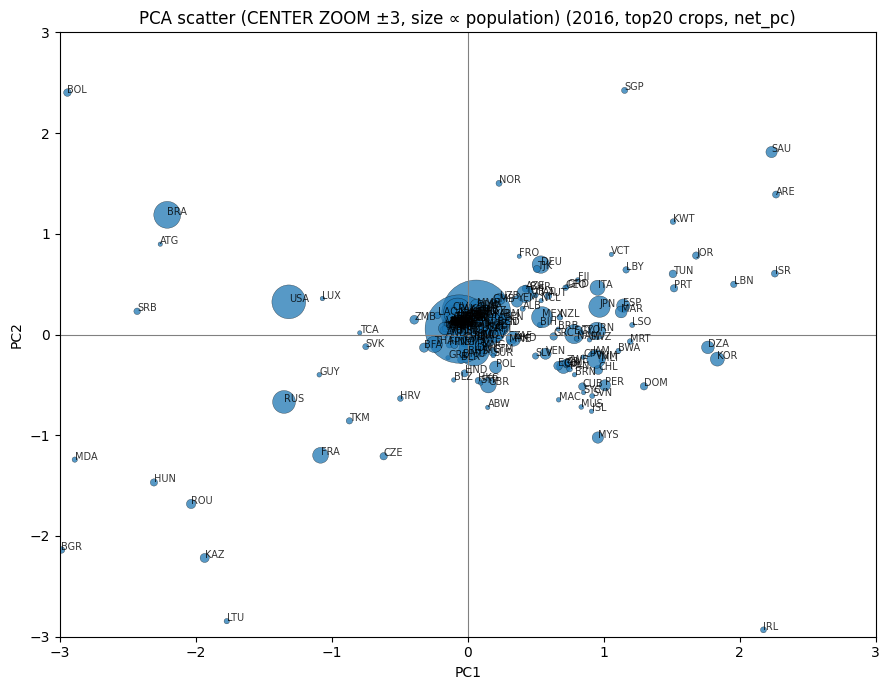

In [14]:
# 2016年・top20作物の各国「一人当たり net(Import-Export)」でPCA + 国の散布図（人口比例サイズ）
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from percapita_utils import build_vwt_trade_npy_store_all_crops, load_vwt_trade_npy_store

# ===== 設定 =====
YEAR = 2016
TOP20_CROP_IDS = [15, 236, 257, 56, 238, 666, 30, 656, 661, 767, 162, 237, 270, 268, 164, 664, 44, 167, 261, 271]
N_COMPONENTS = 5                 # 何主成分まで計算するか
MIN_NON_NAN_FEATURES = 10        # 欠損が多すぎる国を落とす基準
PLOT_PC_X = 1                    # 散布図の横軸 (PC1)
PLOT_PC_Y = 2                    # 散布図の縦軸 (PC2)
ANNOTATE_COUNTRIES = True        # 国コードを点に表示するか
MARKER_SIZE_MIN = 10           # 人口最小時の点サイズ
MARKER_SIZE_MAX = 2500          # 人口最大時の点サイズ
MARKER_USE_LOG_SCALE = False     # 人口を対数スケールでサイズ変換するか

COUNTRY_POP_CSV = r"C:\修論研究\VWT_historical_data\country_population.csv"
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
ITEM_LIST_XLSX = r"C:\修論研究\VWT_historical_data\item_list.xlsx"
VWT_NPY_TEMPLATE = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"

STORE_DIR = Path(r"C:\修論研究\codes\vwt_trade_store_top20_2016")
OUT_DIR = STORE_DIR / "pca_2016_top20_net_pc"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ===== store準備 =====
required = ["iso3_order.npy", "crop_ids.npy", "years.npy", "net_pc.npy", "import_pc.npy", "export_pc.npy", "population_used.npy"]
need_build = any(not (STORE_DIR / f).exists() for f in required)

if not need_build:
    s0 = load_vwt_trade_npy_store(str(STORE_DIR))
    if YEAR not in s0["year_to_idx"] or any(c not in s0["crop_to_idx"] for c in TOP20_CROP_IDS):
        need_build = True

if need_build:
    country_population = pd.read_csv(COUNTRY_POP_CSV)
    summary = build_vwt_trade_npy_store_all_crops(
        crops=TOP20_CROP_IDS,
        year_start=YEAR,
        year_end=YEAR,
        country_list_xlsx=COUNTRY_LIST_XLSX,
        vwt_npy_template=VWT_NPY_TEMPLATE,
        population_df=country_population,
        out_dir=str(STORE_DIR),
        pop_iso3_col="Country Code",
        pop_year_col="Year",
        pop_value_col="Value",
    )
    display(summary)

store = load_vwt_trade_npy_store(str(STORE_DIR))
yi = store["year_to_idx"][YEAR]
iso3 = store["iso3_order"].astype(str)

# ===== crop名マップ =====
def find_col(cols, exact=None, contains=None):
    exact = exact or []
    contains = contains or []
    lowered = {str(c).strip().lower(): c for c in cols}
    for k in exact:
        if k.lower() in lowered:
            return lowered[k.lower()]
    for c in cols:
        low = str(c).strip().lower()
        if all(token in low for token in contains):
            return c
    return None

item_df = pd.read_excel(ITEM_LIST_XLSX)
fao_col = find_col(item_df.columns, exact=["FAO code", "fao code", "FAO_code", "fao_code"], contains=["fao", "code"])
name_col = find_col(item_df.columns, exact=["Commodity name", "commodity name", "Item name", "item name"], contains=["commodity", "name"])

name_map = {}
if fao_col is not None and name_col is not None:
    tmp = item_df[[fao_col, name_col]].copy()
    tmp = tmp.rename(columns={fao_col: "crop_id", name_col: "commodity_name"})
    tmp["crop_id"] = pd.to_numeric(tmp["crop_id"], errors="coerce")
    tmp = tmp.dropna(subset=["crop_id"]).copy()
    tmp["crop_id"] = tmp["crop_id"].astype(int)
    tmp = tmp.drop_duplicates(subset=["crop_id"], keep="first")
    name_map = dict(zip(tmp["crop_id"], tmp["commodity_name"]))

feature_cols = [f"{cid}_{name_map.get(cid, 'unknown')}" for cid in TOP20_CROP_IDS]

# ===== 各国 x 20作物の net_pc 行列 =====
X = np.column_stack([
    store["net_pc"][store["crop_to_idx"][cid], yi, :]
    for cid in TOP20_CROP_IDS
])

df_X = pd.DataFrame(X, index=iso3, columns=feature_cols)

# 人口（同じiso3内でcropごとの差は本来ない想定なので中央値で代表）
POP = np.column_stack([
    store["population_used"][store["crop_to_idx"][cid], yi, :]
    for cid in TOP20_CROP_IDS
])
pop_by_iso3 = pd.Series(np.nanmedian(POP, axis=1), index=iso3, name="population")

# 欠損だらけの国を除外
row_mask = df_X.notna().sum(axis=1) >= MIN_NON_NAN_FEATURES
df_use = df_X.loc[row_mask].copy()
if len(df_use) == 0:
    raise ValueError("有効な国データがありません。MIN_NON_NAN_FEATURES を下げてください。")

# 欠損補完 -> 標準化 -> PCA
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(df_use)

scaler = StandardScaler()
X_std = scaler.fit_transform(X_imp)

n_components = min(N_COMPONENTS, X_std.shape[0], X_std.shape[1])
pca = PCA(n_components=n_components, random_state=0)
scores = pca.fit_transform(X_std)

pc_cols = [f"PC{i+1}" for i in range(n_components)]
scores_df = pd.DataFrame(scores, index=df_use.index, columns=pc_cols).reset_index().rename(columns={"index": "iso3"})

# PCA対象国の人口を付与
scores_df = scores_df.merge(pop_by_iso3.loc[df_use.index].rename("population"), left_on="iso3", right_index=True, how="left")

def population_to_marker_size(pop_series, smin=25, smax=450, use_log=True):
    p = pd.to_numeric(pop_series, errors="coerce")
    size = pd.Series(float(smin), index=p.index)
    valid = p.notna() & (p > 0)
    if valid.sum() == 0:
        return size

    vals = np.log10(p[valid]) if use_log else p[valid]
    vmin = float(vals.min())
    vmax = float(vals.max())

    if np.isclose(vmin, vmax):
        size.loc[valid] = (smin + smax) / 2.0
    else:
        size.loc[valid] = smin + (vals - vmin) / (vmax - vmin) * (smax - smin)
    return size

scores_df["marker_size"] = population_to_marker_size(
    scores_df["population"],
    smin=MARKER_SIZE_MIN,
    smax=MARKER_SIZE_MAX,
    use_log=MARKER_USE_LOG_SCALE,
)

explained_df = pd.DataFrame({
    "PC": pc_cols,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_ratio": np.cumsum(pca.explained_variance_ratio_),
})
loadings_df = pd.DataFrame(pca.components_.T, index=df_use.columns, columns=pc_cols)

# ===== 保存 =====
df_X.to_csv(OUT_DIR / f"input_matrix_net_pc_{YEAR}_iso3_x_top20.csv", encoding="utf-8-sig")
scores_df.to_csv(OUT_DIR / f"pca_scores_{YEAR}.csv", index=False, encoding="utf-8-sig")
explained_df.to_csv(OUT_DIR / f"pca_explained_ratio_{YEAR}.csv", index=False, encoding="utf-8-sig")
loadings_df.to_csv(OUT_DIR / f"pca_loadings_{YEAR}.csv", encoding="utf-8-sig")

print(f"countries used: {len(df_use)} / {len(df_X)}")
print(f"n_components: {n_components}")
print(f"saved: {OUT_DIR}")
print(f"marker size range: {scores_df['marker_size'].min():.1f} - {scores_df['marker_size'].max():.1f}")
display(explained_df)
display(scores_df[["iso3", "population", "marker_size"] + pc_cols].head())
display(loadings_df)

# ===== 国の散布図（PCx-PCy）=====
xcol = f"PC{PLOT_PC_X}"
ycol = f"PC{PLOT_PC_Y}"

if xcol not in scores_df.columns or ycol not in scores_df.columns:
    raise ValueError(f"{xcol} または {ycol} がありません。N_COMPONENTS を増やしてください。")

# -------------------------------
# 図1：全体
# -------------------------------
plt.figure(figsize=(9, 7))

plt.scatter(
    scores_df[xcol],
    scores_df[ycol],
    s=scores_df["marker_size"],
    alpha=0.65,
    edgecolors="black",
    linewidths=0.25,
)

if ANNOTATE_COUNTRIES:
    for _, r in scores_df.iterrows():
        plt.text(r[xcol], r[ycol], r["iso3"], fontsize=6, alpha=0.7)

plt.axhline(0, color="gray", lw=0.8)
plt.axvline(0, color="gray", lw=0.8)

plt.xlabel(xcol)
plt.ylabel(ycol)
plt.title(f"PCA scatter (ALL countries, size ∝ population) ({YEAR}, top20 crops, net_pc)")

plt.tight_layout()
plt.show()

# -------------------------------
# 図2：中心ズーム
# -------------------------------
ZOOM = 3   # ←ズーム範囲（±3σくらいが見やすい）

mask = (
    (scores_df[xcol].abs() < ZOOM) &
    (scores_df[ycol].abs() < ZOOM)
)

scores_zoom = scores_df.loc[mask]

plt.figure(figsize=(9, 7))

plt.scatter(
    scores_zoom[xcol],
    scores_zoom[ycol],
    s=scores_zoom["marker_size"],
    alpha=0.75,
    edgecolors="black",
    linewidths=0.25,
)

if ANNOTATE_COUNTRIES:
    for _, r in scores_zoom.iterrows():
        plt.text(r[xcol], r[ycol], r["iso3"], fontsize=7, alpha=0.8)

plt.axhline(0, color="gray", lw=0.8)
plt.axvline(0, color="gray", lw=0.8)

plt.xlim(-ZOOM, ZOOM)
plt.ylim(-ZOOM, ZOOM)

plt.xlabel(xcol)
plt.ylabel(ycol)
plt.title(f"PCA scatter (CENTER ZOOM ±{ZOOM}, size ∝ population) ({YEAR}, top20 crops, net_pc)")

plt.tight_layout()
plt.show()


Saved trade store: crops=10, years=1, iso3=230, arrays=7 + index(3) at C:\修論研究\codes\vwt_trade_store_top10_2016


,crop,year,pop_year,n_iso3,n_valid_population
0,15,2016,2016,230,210
1,236,2016,2016,230,210
2,257,2016,2016,230,210
3,56,2016,2016,230,210
4,238,2016,2016,230,210
5,666,2016,2016,230,210
6,30,2016,2016,230,210
7,656,2016,2016,230,210
8,661,2016,2016,230,210
9,767,2016,2016,230,210


countries used: 210 / 230
n_components: 5
saved: C:\修論研究\codes\vwt_trade_store_top10_2016\pca_2016_top10_net_pc
marker size range: 25.0 - 450.0


C:\Users\tsuda\AppData\Local\Temp\ipykernel_26204\581908984.py:104: RuntimeWarning: All-NaN slice encountered
  pop_by_iso3 = pd.Series(np.nanmedian(POP, axis=1), index=iso3, name="population")


,PC,explained_variance_ratio,cumulative_ratio
0,PC1,0.214940,0.214940
1,PC2,0.131283,0.346223
2,PC3,0.119017,0.465240
3,PC4,0.105273,0.570513
4,PC5,0.093545,0.664058


,iso3,population,marker_size,PC1,PC2,PC3,PC4,PC5
0,ABW,108727.0,25.029950,-0.063755,0.774389,0.378874,-0.223944,0.544030
1,AFG,34700612.0,35.623532,-0.065046,-0.077360,0.163277,-0.174023,0.075925
2,AGO,29183070.0,33.933814,-0.054058,-0.146074,0.185618,-0.007931,0.075874
3,ALB,2689469.0,25.820288,0.290765,0.028496,-0.011591,0.123901,0.257957
4,AND,72181.0,25.018758,-0.165458,0.205677,-0.097345,0.007865,0.182227


,PC1,PC2,PC3,PC4,PC5
15_Wheat,0.362146,-0.009535,0.212154,0.390729,0.307471
236_Soybeans,0.435673,0.053883,0.183145,-0.152172,-0.025028
257_Palm oil,0.034421,-0.463970,0.459657,-0.071510,0.015939
56_Maize,0.582517,0.115275,-0.190690,0.025874,-0.019204
238_Cake of Soybeans,0.535021,0.082072,-0.255093,-0.171109,-0.202237
666_Chocolate Prsnes,-0.073802,0.593197,-0.021410,-0.107617,0.284919
30_Rice - total (Rice milled equivalent),0.180194,-0.008380,0.648802,-0.209127,0.107004
"656_Coffee, green",0.072360,-0.509329,-0.284045,-0.293500,-0.260553
661_Cocoa beans,0.041341,-0.308748,-0.304120,-0.261991,0.836771
767_Cotton lint,0.086134,-0.234560,-0.118981,0.760931,0.051095


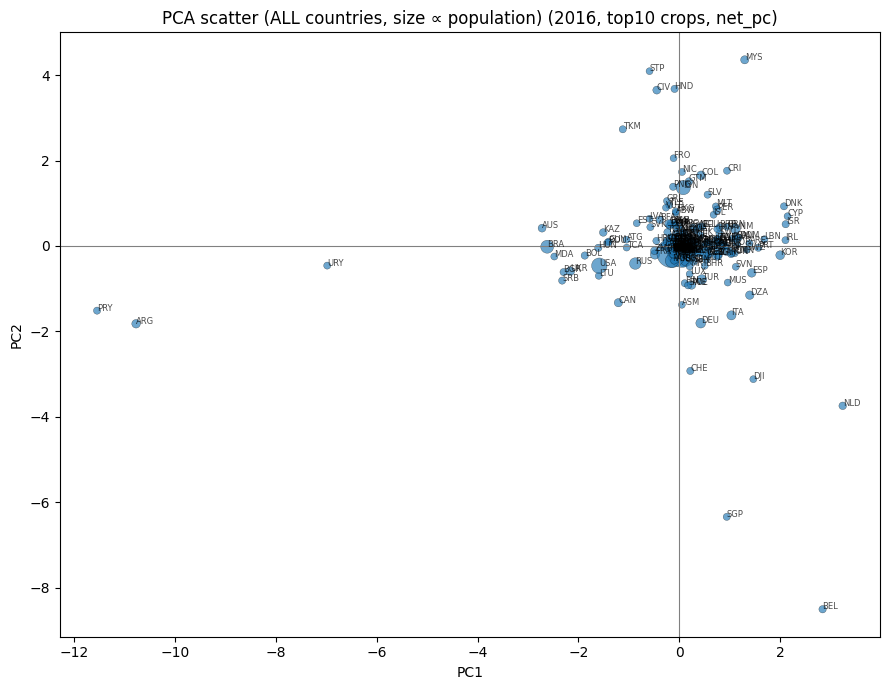

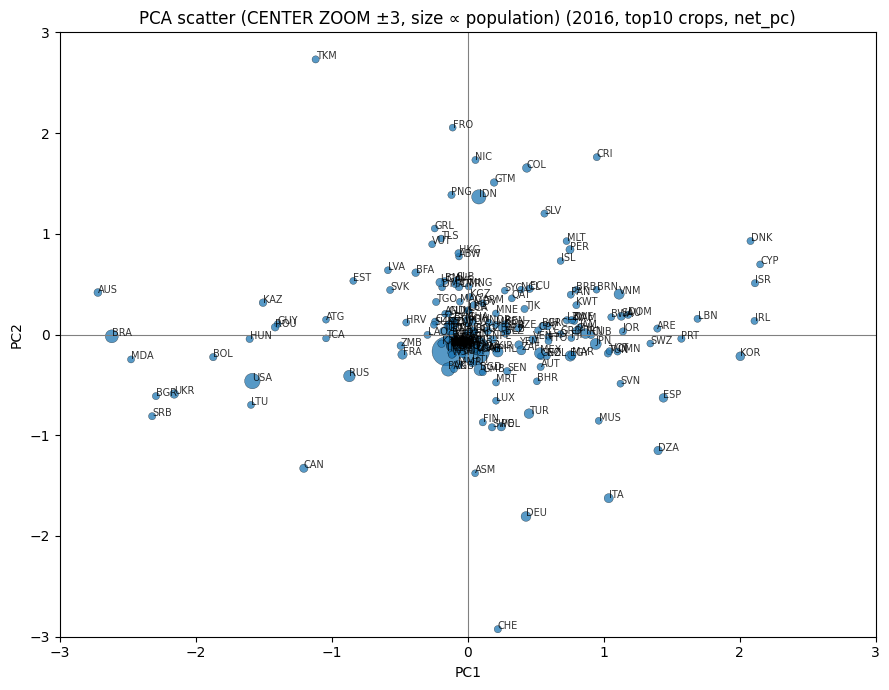

In [15]:
# 2016年・top10作物の各国「一人当たり net(Import-Export)」でPCA + 国の散布図（人口比例サイズ）
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from percapita_utils import build_vwt_trade_npy_store_all_crops, load_vwt_trade_npy_store

# ===== 設定 =====
YEAR = 2016
TOP10_CROP_IDS = [15, 236, 257, 56, 238, 666, 30, 656, 661, 767]
N_COMPONENTS = 5                 # 何主成分まで計算するか
MIN_NON_NAN_FEATURES = 5         # 欠損が多すぎる国を落とす基準（top10なので5以上）
PLOT_PC_X = 1                    # 散布図の横軸 (PC1)
PLOT_PC_Y = 2                    # 散布図の縦軸 (PC2)
ANNOTATE_COUNTRIES = True        # 国コードを点に表示するか
MARKER_SIZE_MIN = 25             # 人口最小時の点サイズ
MARKER_SIZE_MAX = 450            # 人口最大時の点サイズ
MARKER_USE_LOG_SCALE = False     # 人口を線形スケールでサイズ変換

COUNTRY_POP_CSV = r"C:\修論研究\VWT_historical_data\country_population.csv"
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
ITEM_LIST_XLSX = r"C:\修論研究\VWT_historical_data\item_list.xlsx"
VWT_NPY_TEMPLATE = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"

STORE_DIR = Path(r"C:\修論研究\codes\vwt_trade_store_top10_2016")
OUT_DIR = STORE_DIR / "pca_2016_top10_net_pc"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ===== store準備 =====
required = ["iso3_order.npy", "crop_ids.npy", "years.npy", "net_pc.npy", "import_pc.npy", "export_pc.npy", "population_used.npy"]
need_build = any(not (STORE_DIR / f).exists() for f in required)

if not need_build:
    s0 = load_vwt_trade_npy_store(str(STORE_DIR))
    if YEAR not in s0["year_to_idx"] or any(c not in s0["crop_to_idx"] for c in TOP10_CROP_IDS):
        need_build = True

if need_build:
    country_population = pd.read_csv(COUNTRY_POP_CSV)
    summary = build_vwt_trade_npy_store_all_crops(
        crops=TOP10_CROP_IDS,
        year_start=YEAR,
        year_end=YEAR,
        country_list_xlsx=COUNTRY_LIST_XLSX,
        vwt_npy_template=VWT_NPY_TEMPLATE,
        population_df=country_population,
        out_dir=str(STORE_DIR),
        pop_iso3_col="Country Code",
        pop_year_col="Year",
        pop_value_col="Value",
    )
    display(summary)

store = load_vwt_trade_npy_store(str(STORE_DIR))
yi = store["year_to_idx"][YEAR]
iso3 = store["iso3_order"].astype(str)

# ===== crop名マップ =====
def find_col(cols, exact=None, contains=None):
    exact = exact or []
    contains = contains or []
    lowered = {str(c).strip().lower(): c for c in cols}
    for k in exact:
        if k.lower() in lowered:
            return lowered[k.lower()]
    for c in cols:
        low = str(c).strip().lower()
        if all(token in low for token in contains):
            return c
    return None

item_df = pd.read_excel(ITEM_LIST_XLSX)
fao_col = find_col(item_df.columns, exact=["FAO code", "fao code", "FAO_code", "fao_code"], contains=["fao", "code"])
name_col = find_col(item_df.columns, exact=["Commodity name", "commodity name", "Item name", "item name"], contains=["commodity", "name"])

name_map = {}
if fao_col is not None and name_col is not None:
    tmp = item_df[[fao_col, name_col]].copy()
    tmp = tmp.rename(columns={fao_col: "crop_id", name_col: "commodity_name"})
    tmp["crop_id"] = pd.to_numeric(tmp["crop_id"], errors="coerce")
    tmp = tmp.dropna(subset=["crop_id"]).copy()
    tmp["crop_id"] = tmp["crop_id"].astype(int)
    tmp = tmp.drop_duplicates(subset=["crop_id"], keep="first")
    name_map = dict(zip(tmp["crop_id"], tmp["commodity_name"]))

feature_cols = [f"{cid}_{name_map.get(cid, 'unknown')}" for cid in TOP10_CROP_IDS]

# ===== 各国 x 10作物の net_pc 行列 =====
X = np.column_stack([
    store["net_pc"][store["crop_to_idx"][cid], yi, :]
    for cid in TOP10_CROP_IDS
])

df_X = pd.DataFrame(X, index=iso3, columns=feature_cols)

# 人口（同じiso3内でcropごとの差は本来ない想定なので中央値で代表）
POP = np.column_stack([
    store["population_used"][store["crop_to_idx"][cid], yi, :]
    for cid in TOP10_CROP_IDS
])
pop_by_iso3 = pd.Series(np.nanmedian(POP, axis=1), index=iso3, name="population")

# 欠損だらけの国を除外
row_mask = df_X.notna().sum(axis=1) >= MIN_NON_NAN_FEATURES
df_use = df_X.loc[row_mask].copy()
if len(df_use) == 0:
    raise ValueError("有効な国データがありません。MIN_NON_NAN_FEATURES を下げてください。")

# 欠損補完 -> 標準化 -> PCA
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(df_use)

scaler = StandardScaler()
X_std = scaler.fit_transform(X_imp)

n_components = min(N_COMPONENTS, X_std.shape[0], X_std.shape[1])
pca = PCA(n_components=n_components, random_state=0)
scores = pca.fit_transform(X_std)

pc_cols = [f"PC{i+1}" for i in range(n_components)]
scores_df = pd.DataFrame(scores, index=df_use.index, columns=pc_cols).reset_index().rename(columns={"index": "iso3"})

# PCA対象国の人口を付与
scores_df = scores_df.merge(pop_by_iso3.loc[df_use.index].rename("population"), left_on="iso3", right_index=True, how="left")

def population_to_marker_size(pop_series, smin=25, smax=450, use_log=True):
    p = pd.to_numeric(pop_series, errors="coerce")
    size = pd.Series(float(smin), index=p.index)
    valid = p.notna() & (p > 0)
    if valid.sum() == 0:
        return size

    vals = np.log10(p[valid]) if use_log else p[valid]
    vmin = float(vals.min())
    vmax = float(vals.max())

    if np.isclose(vmin, vmax):
        size.loc[valid] = (smin + smax) / 2.0
    else:
        size.loc[valid] = smin + (vals - vmin) / (vmax - vmin) * (smax - smin)
    return size

scores_df["marker_size"] = population_to_marker_size(
    scores_df["population"],
    smin=MARKER_SIZE_MIN,
    smax=MARKER_SIZE_MAX,
    use_log=MARKER_USE_LOG_SCALE,
)

explained_df = pd.DataFrame({
    "PC": pc_cols,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_ratio": np.cumsum(pca.explained_variance_ratio_),
})
loadings_df = pd.DataFrame(pca.components_.T, index=df_use.columns, columns=pc_cols)

# ===== 保存 =====
df_X.to_csv(OUT_DIR / f"input_matrix_net_pc_{YEAR}_iso3_x_top10.csv", encoding="utf-8-sig")
scores_df.to_csv(OUT_DIR / f"pca_scores_{YEAR}.csv", index=False, encoding="utf-8-sig")
explained_df.to_csv(OUT_DIR / f"pca_explained_ratio_{YEAR}.csv", index=False, encoding="utf-8-sig")
loadings_df.to_csv(OUT_DIR / f"pca_loadings_{YEAR}.csv", encoding="utf-8-sig")

print(f"countries used: {len(df_use)} / {len(df_X)}")
print(f"n_components: {n_components}")
print(f"saved: {OUT_DIR}")
print(f"marker size range: {scores_df['marker_size'].min():.1f} - {scores_df['marker_size'].max():.1f}")
display(explained_df)
display(scores_df[["iso3", "population", "marker_size"] + pc_cols].head())
display(loadings_df)

# ===== 国の散布図（PCx-PCy）=====
xcol = f"PC{PLOT_PC_X}"
ycol = f"PC{PLOT_PC_Y}"

if xcol not in scores_df.columns or ycol not in scores_df.columns:
    raise ValueError(f"{xcol} または {ycol} がありません。N_COMPONENTS を増やしてください。")

# -------------------------------
# 図1：全体
# -------------------------------
plt.figure(figsize=(9, 7))

plt.scatter(
    scores_df[xcol],
    scores_df[ycol],
    s=scores_df["marker_size"],
    alpha=0.65,
    edgecolors="black",
    linewidths=0.25,
)

if ANNOTATE_COUNTRIES:
    for _, r in scores_df.iterrows():
        plt.text(r[xcol], r[ycol], r["iso3"], fontsize=6, alpha=0.7)

plt.axhline(0, color="gray", lw=0.8)
plt.axvline(0, color="gray", lw=0.8)

plt.xlabel(xcol)
plt.ylabel(ycol)
plt.title(f"PCA scatter (ALL countries, size ∝ population) ({YEAR}, top10 crops, net_pc)")

plt.tight_layout()
plt.show()

# -------------------------------
# 図2：中心ズーム
# -------------------------------
ZOOM = 3   # ←ズーム範囲（±3σくらいが見やすい）

mask = (
    (scores_df[xcol].abs() < ZOOM) &
    (scores_df[ycol].abs() < ZOOM)
)

scores_zoom = scores_df.loc[mask]

plt.figure(figsize=(9, 7))

plt.scatter(
    scores_zoom[xcol],
    scores_zoom[ycol],
    s=scores_zoom["marker_size"],
    alpha=0.75,
    edgecolors="black",
    linewidths=0.25,
)

if ANNOTATE_COUNTRIES:
    for _, r in scores_zoom.iterrows():
        plt.text(r[xcol], r[ycol], r["iso3"], fontsize=7, alpha=0.8)

plt.axhline(0, color="gray", lw=0.8)
plt.axvline(0, color="gray", lw=0.8)

plt.xlim(-ZOOM, ZOOM)
plt.ylim(-ZOOM, ZOOM)

plt.xlabel(xcol)
plt.ylabel(ycol)
plt.title(f"PCA scatter (CENTER ZOOM ±{ZOOM}, size ∝ population) ({YEAR}, top10 crops, net_pc)")

plt.tight_layout()
plt.show()
